<a href="https://colab.research.google.com/github/aparna-2001/deep_learning_practice/blob/main/Predicting_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Classification on Tabular Data - Predictng Heart Disease

This is a practice notebook I have done from MIT OCW deep learning lectures

##Introduction

* Neural Network model for binary classification
* Here the dataset is tabular rather than unstructured and has a mix of numeric and categorical features.

## The dataset

* The dataset (https://archive.ics.uci.edu/ml/datasets/heart+Disease) contains information on 303 patients, one in each row. Each column contains information on a particular attribute of the patient. The column named "Target" indicates if the patient has been diagnosed with heart disease or not and is the label we want to predict using the other columns

##Technical preliminaries

In [1]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Randomness enters in;
 * Starting values of the weights(the optimizer will try to improve the weights)
 * The order in which we process the minibatches when we do SGD
 * When we split the data into Train, Validation, Test etc
 * Dropout(if we use regularization)

 setting the seed for different random number generator so that the results will be the same every time the notebook is run.

In [2]:
keras.utils.set_random_seed(42)

## Reading the data

In [3]:
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")

In [4]:
df.shape

(303, 14)

The dataset has 303 rows and 14 columns (13 dependant variable and 1 independant variable)

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [6]:
df.target.value_counts(normalize=True, dropna=False)

,proportion
target,
0,0.726073
1,0.273927


It is a bit imbalanced.

* A basline model would be just predict a probability of 0.0 for every pateint. That will result in 72.6% accuracy.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 33.3+ KB


## Preprocessing

In [8]:
categorical_variables = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'ca', 'thal']
numerics = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope']

NN's require all their inputs to be numeric so we will preprocess this raw data as follows;

* *one-hot encode* the categorical variables
* *normalize* the numeric variables

In [9]:
df = pd.get_dummies(df, columns= categorical_variables)

In [10]:
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


Standaridize the numerals;

Before standardize, let's split the data into an 80% training set and 20% test set

In [11]:
test_df= df.sample(frac=0.2, random_state=42)
train_df= df.drop(test_df.index)

In [12]:
train_df.shape

(242, 30)

In [13]:
test_df.shape

(61, 30)

Calculate the mean and standard deviation of every numeric variable in the training set

In [14]:
means = train_df[numerics].mean()
sd = train_df[numerics].std()

In [15]:
means

,0
age,54.268595
trestbps,131.995868
chol,246.512397
thalach,149.805785
oldpeak,1.032645
slope,1.590909


Standardizing the train and test dataframes with the above means and standard deviations

In [16]:
train_df[numerics] = (train_df[numerics]-means)/sd

In [17]:
test_df[numerics] = (test_df[numerics]- means)/sd

In [18]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


Now data is all numeric

For feeding data into Keras/Tensorflow, we convert the train and test data into numpy arrays

In [19]:
train = train_df.to_numpy()
test = test_df.to_numpy()

Removing the target variable

In [20]:
train_X=np.delete(train, 6, axis=1)
test_X=np.delete(test, 6, axis=1)

In [21]:
train_X.shape, test_X.shape

((242, 29), (61, 29))

In [22]:
train_y = train[:, 6]
test_y = test[:, 6]

In [23]:
train_y.shape, test_y.shape

((242,), (61,))

##Building a model

* Single hidden layer
* Since this is a binary classification problem, we use sigmoid function as the output layer

In [24]:
num_columns = train_X.shape[1]

#defining the input layer

input = keras.Input(shape=(num_columns,))

#feeding the input layer to hidden layer

hidden = keras.layers.Dense(16, activation='relu', name="Hidden")(input)

#feeding the output of the hidden layer to the output layer

output = keras.layers.Dense(1, activation='sigmoid', name='Output')(hidden)

#telling keras that this(input, output) pair is the model
model = keras.Model(input, output)

In [25]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

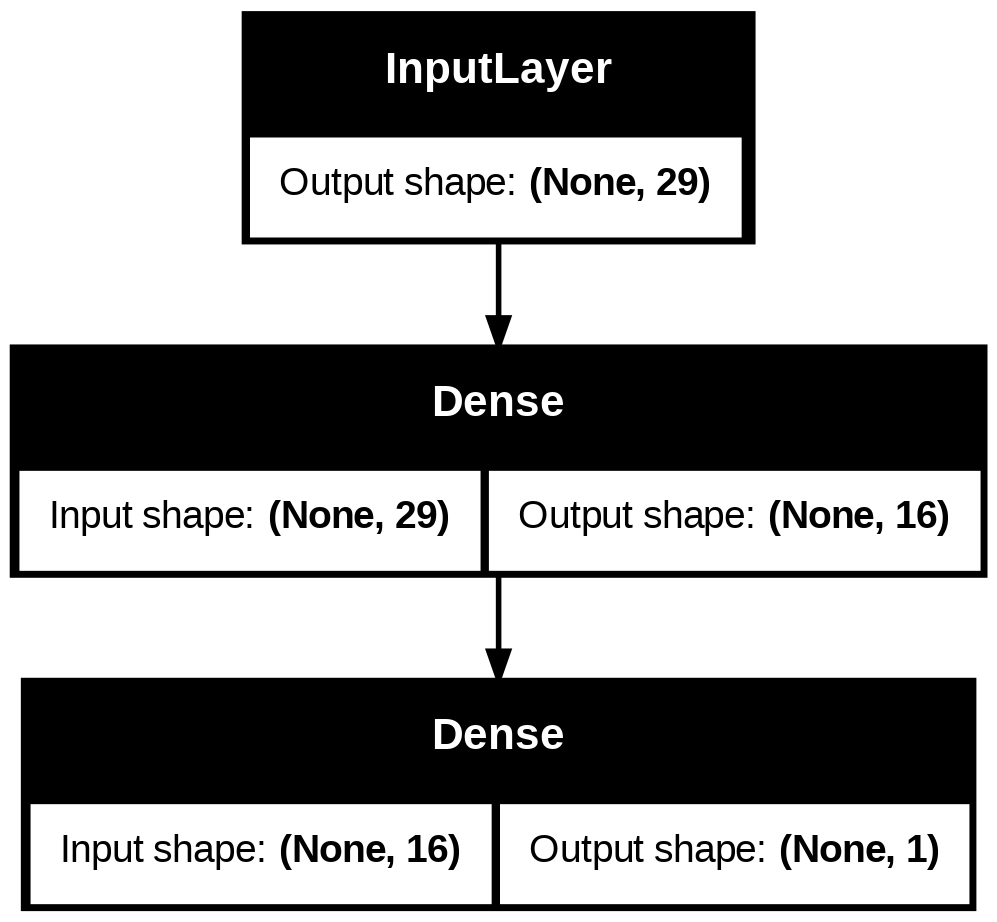

In [26]:
keras.utils.plot_model(model, show_shapes=True)

##Setting optimization parameters

* **Loss function** to use -since our output variable is binary, we will select the `binary_crossentropy` loss function.
* **Optimizer** to use - we will use sibling of SGD called **Adam**
* **Metrics** to report - in classification problems, **Accuracy** is usually the metric we use.

In [27]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

##Training the model

* Batch size - 32 (a good default)
* Number of epochs - how many passes through the training data. Usually 20-30 epochs is a good starting point but since the dataset is very small, each epoch will be very quick, so let's run it for 300 epochs. It will allow us to see if any overfitting happens.
* Whether to use a validation set- This will be useful for overfitting detection and regularizatiob via early stopping so we will ask Keras to automatically use 20% of the data points as a validation set.

In [28]:
history = model.fit(train_X.astype(np.float32),
          train_y.astype(np.float32),
          epochs=300,
          batch_size=32,
          verbose=1,
          validation_split=0.2)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5596 - loss: 0.7154 - val_accuracy: 0.5918 - val_loss: 0.6891
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6062 - loss: 0.6826 - val_accuracy: 0.6122 - val_loss: 0.6697
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6321 - loss: 0.6586 - val_accuracy: 0.6122 - val_loss: 0.6530
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6528 - loss: 0.6376 - val_accuracy: 0.6122 - val_loss: 0.6372
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6736 - loss: 0.6181 - val_accuracy: 0.6531 - val_loss: 0.6225
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6995 - loss: 0.5995 - val_accuracy: 0.6939 - val_loss: 0.6088
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7358 - loss: 0.5822 - val_accuracy: 0.6939 - val_loss: 0.5959
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7513 - loss: 0.5658 - val_accuracy: 0.7143 - val_loss:

In [29]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

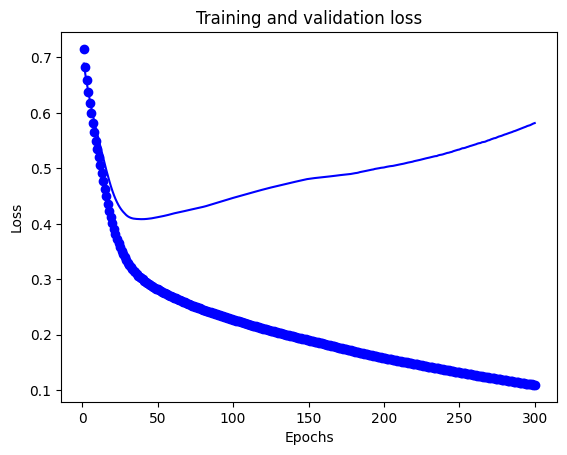

In [30]:
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values)+ 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label="Validation loss")
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

There seems to be some overfitting

If there is overfitting at N number of epochs, we could go back and reinitilaise to N epochs - that would be an example of **Early stoopping**

*Accuray curves*

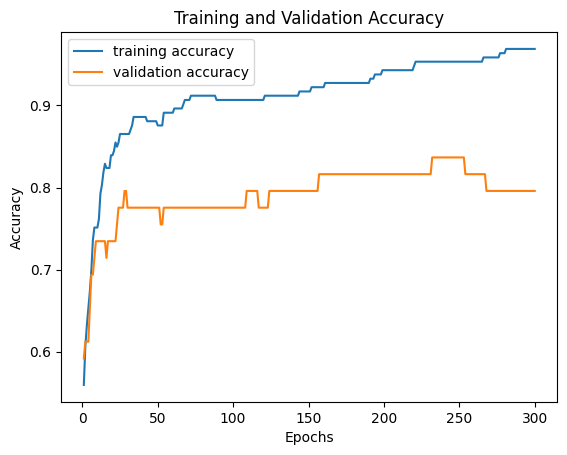

In [33]:


plt.clf()

training_acc = history_dict['accuracy']
validation_acc = history_dict['val_accuracy']


plt.plot(epochs, training_acc, label='training accuracy')
plt.plot(epochs, validation_acc, label='validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Evaluating the model**

How well the model works on the test set

In [39]:
model.evaluate(test_X.astype(np.float32), test_y.astype(np.float32))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8361 - loss: 0.4810


[0.4810093939304352, 0.8360655903816223]

* Accuracy 0.8361